# Example for the modularized peakTree with MIRA

- using the Mira znc format

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt

import numpy as np

import cmcrameri.cm as cmc

import sys
sys.path.append('../peakTree/')
import peakTree

/home/miratools/peakTree_processing/dev_modularised/../peakTree/peakTree/__init__.py:540: SyntaxWarning: invalid escape sequence '\d'
  self.cal_constant = float(re.findall("[+-]\d+.\d+", self.f.cal_constant)[0])


In [3]:
%matplotlib inline

In [4]:
files = sorted(list(Path('/data/level0/mira35/2023').glob('20231228*.znc')))
files

[PosixPath('/data/level0/mira35/2023/20231228_000013.znc'),
 PosixPath('/data/level0/mira35/2023/20231228_030014.znc'),
 PosixPath('/data/level0/mira35/2023/20231228_060014.znc'),
 PosixPath('/data/level0/mira35/2023/20231228_090014.znc'),
 PosixPath('/data/level0/mira35/2023/20231228_120014.znc'),
 PosixPath('/data/level0/mira35/2023/20231228_150014.znc'),
 PosixPath('/data/level0/mira35/2023/20231228_180014.znc'),
 PosixPath('/data/level0/mira35/2023/20231228_210014.znc')]

## Mira specific preprocessing

In [5]:
with xr.open_dataset(files[3]) as ds:
    ds['time'] = (ds['time']*1e6 + ds['microsec']).astype('datetime64[us]')

    # shorten the duration for the showcase
    ds = ds.sel(time=slice("2023-12-28T09:00", "2023-12-28T10:00"))

ds

<xarray.Dataset> Size: 5GB
Dimensions:          (time: 1186, range: 496, doppler: 512)
Coordinates:
  * time             (time) datetime64[us] 9kB 2023-12-28T09:00:10.793629 ......
  * range            (range) float32 2kB 155.9 187.1 ... 1.556e+04 1.559e+04
  * doppler          (doppler) float32 2kB 0.0 0.04124 ... -0.08247 -0.04123
Data variables: (12/38)
    nfft             int32 4B ...
    prf              int32 4B ...
    NyquistVelocity  float32 4B ...
    nave             int32 4B ...
    ovl              int32 4B ...
    zrg              int32 4B ...
    ...               ...
    SPCcocxIm        (time, range, doppler) float32 1GB ...
    MRMco            (time) float32 5kB ...
    MRMcx            (time) float32 5kB ...
    RadarConst       (time) float32 5kB ...
    SNRCorFaCo       (time, range) float32 2MB ...
    SNRCorFaCx       (time, range) float32 2MB ...
Attributes: (12/15)
    convention:       CF-1.0
    location:         Neumayer
    Altitude:         60 m
    Latitude:         70.66518 S
    Longitude:        8.28367 W
    system:           IFTmira-36
    ...               ...
    reference:        Ka Band Cloud Radar MIRA, METEK GmbH www.metek.de
    ppar:             PRF:        5000\nPDR:         208\nSFT:           2\nA...
    hrd:              NAME:231228_090007.pds.off\nOPER:Thu Dec 28 09:00:07 20...
    Copyright:        Any use of these data is subject to a copyright agreeme...
    Copyright_Owner:  TROPOS
    notes:            It is accounted for the Receiver Bwd Loss in Radarconst...

In [6]:

Z = ds['SPCco'] / ds['npw1'] * ds['RadarConst'] * (ds['range'] / 5e3)**2 * ds['SNRCorFaCo']
Z.attrs['long_name'] = 'Spectral reflectivity'

nfft = ds['doppler'].values.shape[0]
noise = ds['HSDco'] * ds['RadarConst'] * (ds['range'] / 5e3)**2 / nfft 

Zcx = ds['SPCcx'] / ds['npw2'] * ds['RadarConst'] * (ds['range'] / 5e3)**2 * ds['SNRCorFaCx']

no_roll = int(ds['doppler'].shape[0]/2)
print('no_roll', no_roll)
Z = Z.roll(doppler=no_roll, roll_coords=True).isel(doppler=slice(None, None, -1))
Zcx = Zcx.roll(doppler=no_roll, roll_coords=True).isel(doppler=slice(None, None, -1))
Z['doppler'] = Z['doppler']*-1
Zcx['doppler'] = Zcx['doppler']*-1


ds_input = xr.Dataset(
    data_vars={
        "Z": Z,
        "Zcx": Zcx,
        "noise": noise,
    }
)

no_roll 256


In [7]:
ds_input = ds_input.resample(time="6.2s").mean()

In [8]:
ds_input

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 589, range: 496, doppler: 512)
Coordinates:
  * time     (time) datetime64[us] 5kB 2023-12-28T09:00:07.400000 ... 2023-12...
  * range    (range) float32 2kB 155.9 187.1 218.3 ... 1.556e+04 1.559e+04
  * doppler  (doppler) float32 2kB -10.52 -10.47 -10.43 ... 10.47 10.52 10.56
Data variables:
    Z        (time, range, doppler) float32 598MB 5.134e-05 ... 0.0003961
    Zcx      (time, range, doppler) float32 598MB 2.263e-06 ... 0.0003407
    noise    (time, range) float32 1MB 2.555e-07 3.995e-07 ... 0.000257

In [9]:

ds_input['noise_mask'] = ds_input['Z'] < ds_input['noise']*1.3
ds_input = ds_input.drop_vars('noise')
ds_input

<xarray.Dataset> Size: 1GB
Dimensions:     (time: 589, range: 496, doppler: 512)
Coordinates:
  * time        (time) datetime64[us] 5kB 2023-12-28T09:00:07.400000 ... 2023...
  * range       (range) float32 2kB 155.9 187.1 218.3 ... 1.556e+04 1.559e+04
  * doppler     (doppler) float32 2kB -10.52 -10.47 -10.43 ... 10.47 10.52 10.56
Data variables:
    Z           (time, range, doppler) float32 598MB 5.134e-05 ... 0.0003961
    Zcx         (time, range, doppler) float32 598MB 2.263e-06 ... 0.0003407
    noise_mask  (time, range, doppler) bool 150MB False False ... False False

(0.0, 3000.0)

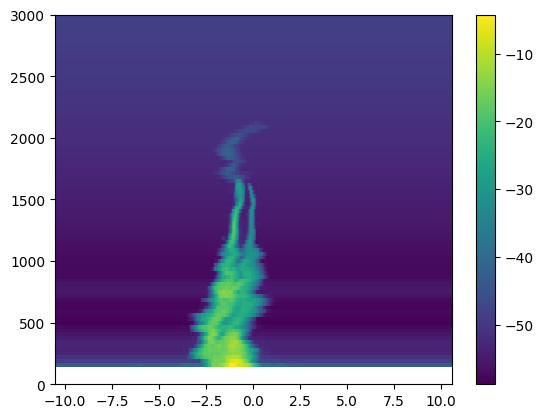

In [10]:
# Arbitrary example spectrogram

ds_rgspecgramm = ds_input.isel(time=4)

fig, ax = plt.subplots()
pcmesh = ax.pcolormesh(
    ds_rgspecgramm.doppler, ds_rgspecgramm.range, 
    10*np.log10(ds_rgspecgramm['Z']),
)
fig.colorbar(pcmesh)
ax.set_ylim(0,3000)

## Convert to tree structure

In [12]:
meta={
    'Z': ['M0', 'M1', 'M2', 'M3', 'P'],
    'Zcx': ['M0', 'P'],
    }


ds_rect = peakTree.ds_to_tree(
    ds_input,
    {'width_thres': 0.1, 'prom_thres': 1},
    meta
)

<unknown>:540: SyntaxWarning: invalid escape sequence '\d'
<unknown>:540: SyntaxWarning: invalid escape sequence '\d'
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
temporary fix for the prominence of equally high peaks
te

## Post-processing and storage

In [13]:
ds_rect

<xarray.Dataset> Size: 388MB
Dimensions:       (time: 589, range: 496, node: 15)
Coordinates:
  * time          (time) datetime64[us] 5kB 2023-12-28T09:00:07.400000 ... 20...
  * range         (range) float32 2kB 155.9 187.1 218.3 ... 1.556e+04 1.559e+04
Dimensions without coordinates: node
Data variables:
    bounds_left   (time, range, node) float64 35MB 152.0 152.0 ... -999.0 -999.0
    bounds_right  (time, range, node) float64 35MB 366.0 333.0 ... -999.0 -999.0
    parent_id     (time, range, node) float64 35MB -1.0 0.0 ... -999.0 -999.0
    thres         (time, range, node) float64 35MB 4.722e-05 ... -999.0
    Z_M0          (time, range, node) float64 35MB 10.0 10.0 ... -999.0 -999.0
    Z_M1          (time, range, node) float64 35MB -0.7 -0.7009 ... -999.0
    Z_M2          (time, range, node) float64 35MB 0.4187 0.4138 ... -999.0
    Z_M3          (time, range, node) float64 35MB -0.292 -0.573 ... -999.0
    Z_P           (time, range, node) float64 35MB 1.311e+04 ... -999.0
    Zcx_M0        (time, range, node) float64 35MB 0.115 0.115 ... -999.0 -999.0
    Zcx_P         (time, range, node) float64 35MB 138.8 138.8 ... -999.0 -999.0
    no_nodes      (time, range) int64 2MB 7 5 7 7 7 5 3 5 3 ... 0 0 0 0 0 0 0 0
Attributes:
    long_name:  Doppler Velocity
    units:      m/s
    axis:       V

In [14]:

ds_rect['LDR'] = xr.where(
    ds_rect['Zcx_M0'] < 10**(-40/10), -999, ds_rect['Zcx_M0'] / ds_rect['Z_M0'])

In [15]:
dt = ds_rect.time.values[0].astype('datetime64[us]').astype('O')
ds_rect.to_netcdf(
    path=f'{dt:%Y%m%d_%H%M}_mira_peakTree.nc4'
)

## Plotting

In [16]:

ds_filled = ds_rect.where(ds_rect != -999, np.nan)

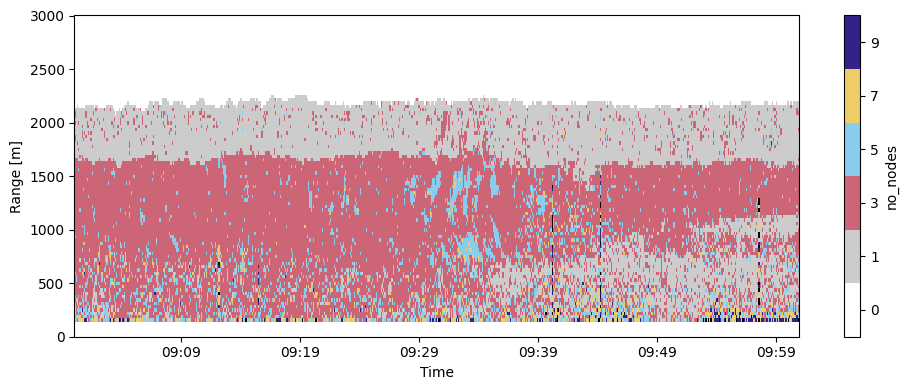

In [17]:
cat_cmap = matplotlib.colors.ListedColormap(
    ["#ffffff", "#cccccc", "#cc6677", "#88ccee", "#eecc66", "#332288"], 'pTcat') 
cat_cmap.set_over("#000000")
# even number of nodes is not possible in binary tree
# thus these values can be omitted
labels = {0: '0', 1: "1", 2: "3", 3: "5", 4: "7", 5: "9"}
no_nodes_plot = np.ceil(ds_filled['no_nodes']/2.)

fig, ax = plt.subplots(figsize=(10,4))

pcmesh = ax.pcolormesh(
    ds_filled['no_nodes']['time'], ds_filled['no_nodes']['range'], no_nodes_plot.T,
    shading = 'nearest',
    cmap=cat_cmap,
    vmin=-0.5, vmax=5.5,
)

ax.set_ylabel('Range [m]')
ax.set_xlabel('Time')
ax.xaxis.set_major_locator(matplotlib.dates.MinuteLocator(interval=10))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))
cbar = fig.colorbar(pcmesh, ticks=list(labels.keys()), label='no_nodes')
cbar.ax.set_yticklabels(labels.values())

ax.set_ylim(0,3000)
fig.tight_layout()

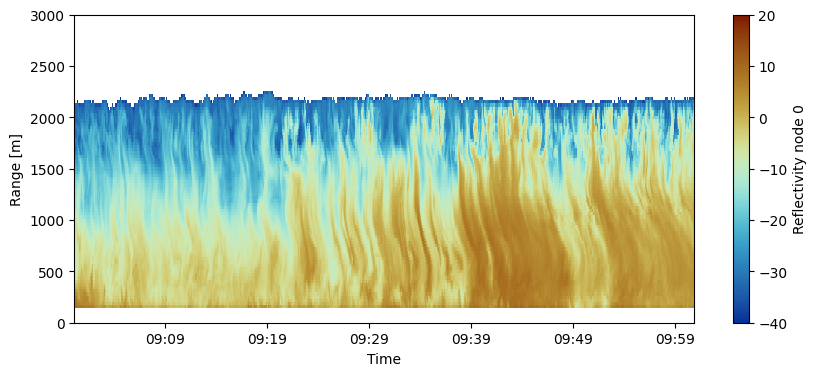

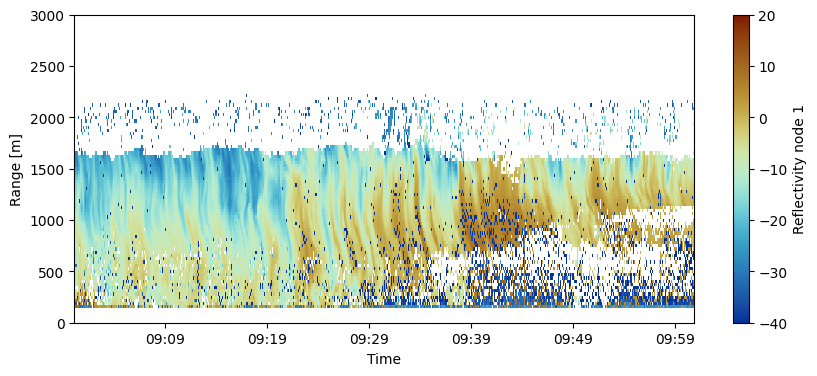

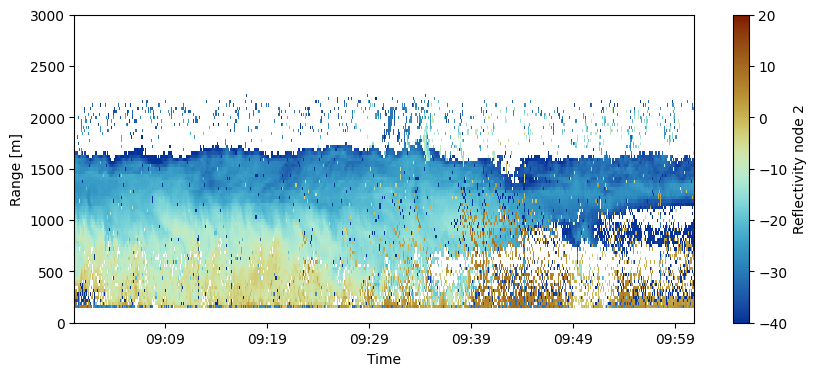

In [ ]:

for i in [0,1,2]:
    fig, ax = plt.subplots(figsize=(10,4))

    pcmesh = ax.pcolormesh(
        ds_filled['time'], ds_filled['range'], 10*np.log10(ds_filled['Z_M0'].isel(node=i)).T,
        shading = 'nearest',
        vmin=-40, vmax=20,
        cmap=cmc.roma_r
    )

    ax.set_ylabel('Range [m]')
    ax.set_xlabel('Time')
    ax.xaxis.set_major_locator(matplotlib.dates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))
    fig.colorbar(pcmesh, label=f'Reflectivity node {i}')

    ax.set_ylim(0,3000)

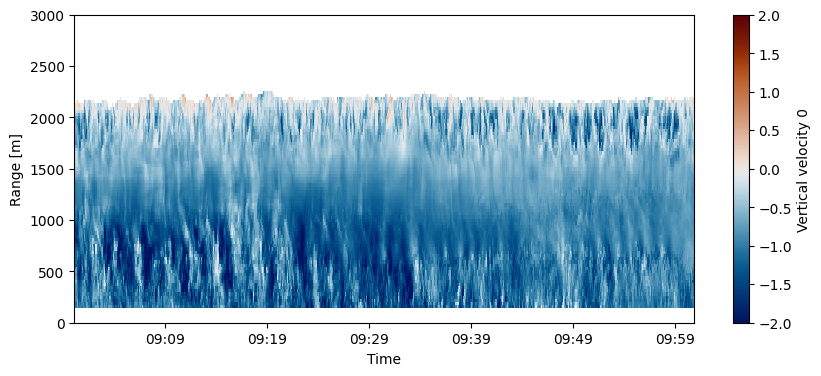

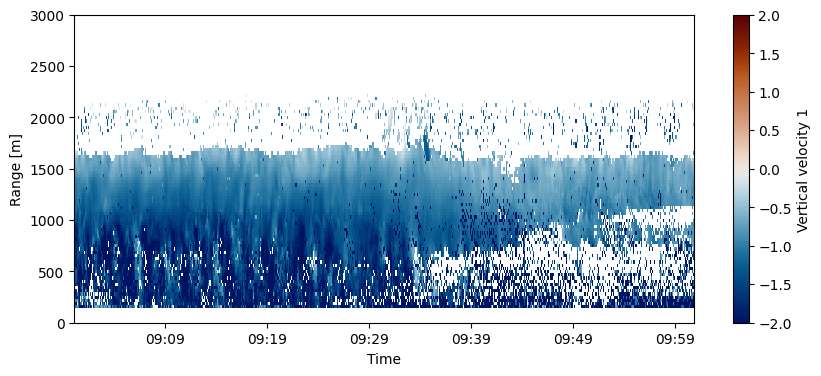

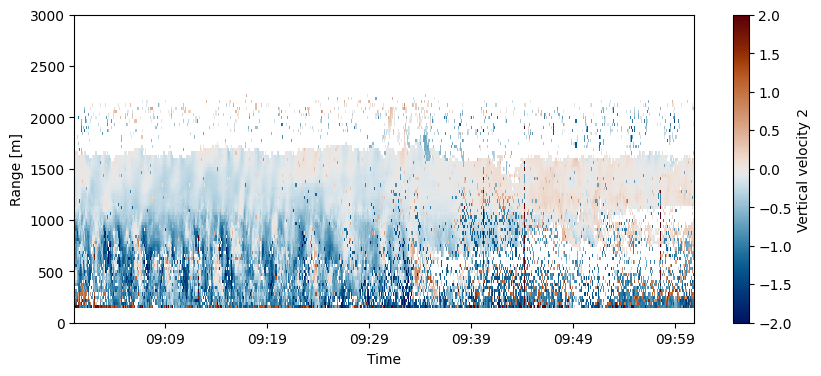

In [ ]:

for i in [0,1,2]:
    fig, ax = plt.subplots(figsize=(10,4))

    pcmesh = ax.pcolormesh(
        ds_filled['time'], ds_filled['range'], ds_filled['Z_M1'].isel(node=i).T,
        shading = 'nearest',
        vmin=-2, vmax=2,
        cmap=cmc.vik
    )

    ax.set_ylabel('Range [m]')
    ax.set_xlabel('Time')
    ax.xaxis.set_major_locator(matplotlib.dates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))
    fig.colorbar(pcmesh, label=f'Vertical velocity node {i}')

    ax.set_ylim(0,3000)

/home/miratools/peakTree_processing/p312-peaktree/lib/python3.12/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


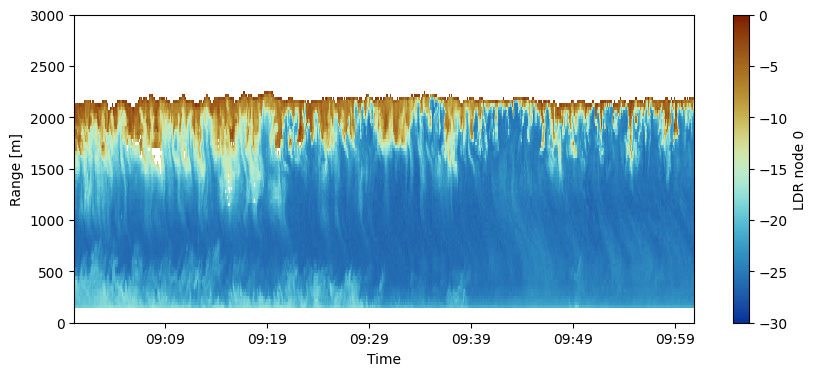

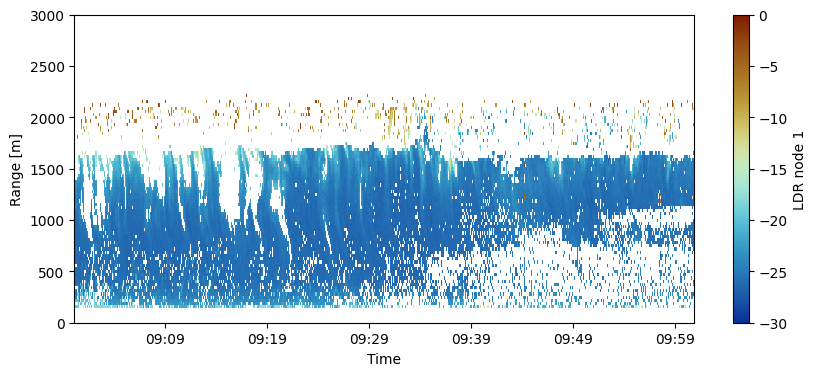

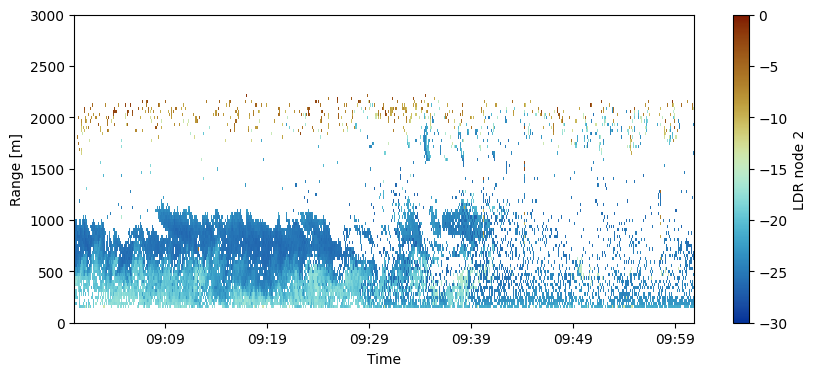

In [ ]:

for i in [0,1,2]:
    fig, ax = plt.subplots(figsize=(10,4))

    pcmesh = ax.pcolormesh(
        ds_rect['time'], ds_rect['range'], 10*np.log10(ds_rect['LDR'].isel(node=i)).T,
        shading = 'nearest',
        vmin=-30, vmax=0,
        cmap=cmc.roma_r
    )

    ax.set_ylabel('Range [m]')
    ax.set_xlabel('Time')
    ax.xaxis.set_major_locator(matplotlib.dates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H:%M'))
    fig.colorbar(pcmesh, label=f'LDR node {i}')

    ax.set_ylim(0,3000)